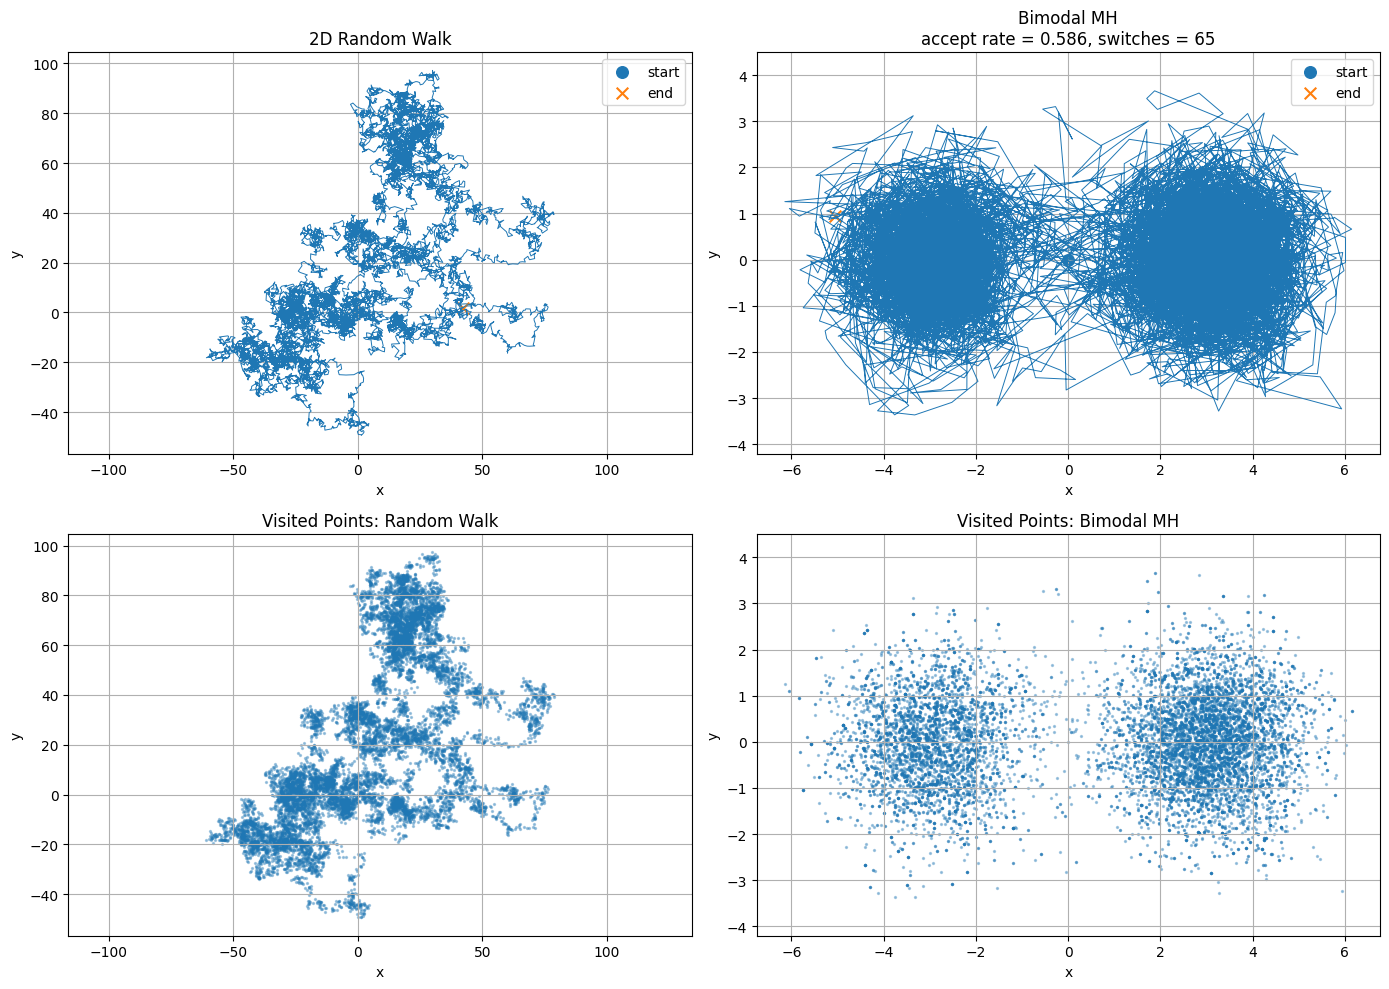

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 設定
# =========================================
np.random.seed(42)
n_steps = 12000
rw_step_std = 1.0
mh_proposal_std = 0.9

# =========================================
# 二峰性分布
# 0.5 * N(mu1, I) + 0.5 * N(mu2, I)
# =========================================
mu1 = np.array([-3.0, 0.0])
mu2 = np.array([ 3.0, 0.0])

def gaussian_2d(x, mu):
    diff = x - mu
    return np.exp(-0.5 * np.sum(diff**2))

def target_density_point(x):
    return 0.5 * gaussian_2d(x, mu1) + 0.5 * gaussian_2d(x, mu2)

def log_target(x):
    return np.log(target_density_point(x) + 1e-300)

# =========================================
# 1. 2次元ランダムウォーク
# =========================================
rw = np.zeros((n_steps, 2))

for t in range(1, n_steps):
    step = np.random.normal(0, rw_step_std, size=2)
    rw[t] = rw[t - 1] + step

# =========================================
# 2. Metropolis-Hastings
# =========================================
mh = np.zeros((n_steps, 2))
current = np.array([0.0, 0.0])
accepted = 0

for t in range(1, n_steps):
    proposal = current + np.random.normal(0, mh_proposal_std, size=2)

    log_alpha = log_target(proposal) - log_target(current)

    if np.log(np.random.rand()) < log_alpha:
        current = proposal
        accepted += 1

    mh[t] = current

accept_rate = accepted / (n_steps - 1)

# =========================================
# 山の切り替わり回数
# =========================================
side = np.where(mh[:, 0] < 0, -1, 1)
switches = np.sum(side[1:] != side[:-1])

# =========================================
# 描画
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- 左上: ランダムウォーク軌跡 ----
axes[0, 0].plot(rw[:, 0], rw[:, 1], linewidth=0.7)
axes[0, 0].scatter(rw[0, 0], rw[0, 1], s=70, marker='o', label='start')
axes[0, 0].scatter(rw[-1, 0], rw[-1, 1], s=70, marker='x', label='end')
axes[0, 0].set_title("2D Random Walk")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[0, 0].axis("equal")
axes[0, 0].grid(True)
axes[0, 0].legend()

# ---- 右上: MH軌跡 ----
axes[0, 1].plot(mh[:, 0], mh[:, 1], linewidth=0.7)
axes[0, 1].scatter(mh[0, 0], mh[0, 1], s=70, marker='o', label='start')
axes[0, 1].scatter(mh[-1, 0], mh[-1, 1], s=70, marker='x', label='end')
axes[0, 1].set_title(f"Bimodal MH\naccept rate = {accept_rate:.3f}, switches = {switches}")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("y")
axes[0, 1].axis("equal")
axes[0, 1].grid(True)
axes[0, 1].legend()

# ---- 左下: ランダムウォーク訪問点 ----
axes[1, 0].scatter(rw[:, 0], rw[:, 1], s=2, alpha=0.35)
axes[1, 0].set_title("Visited Points: Random Walk")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("y")
axes[1, 0].axis("equal")
axes[1, 0].grid(True)

# ---- 右下: MH訪問点 ----
axes[1, 1].scatter(mh[:, 0], mh[:, 1], s=2, alpha=0.35)
axes[1, 1].set_title("Visited Points: Bimodal MH")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("y")
axes[1, 1].axis("equal")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()